In [132]:
import torch 
import numpy as np 
import matplotlib.pyplot as plt 
import torch.nn.functional as F
from torch.utils.data import DataLoader , TensorDataset
from sklearn.datasets import load_iris
import torch.nn as nn
from sklearn.metrics import accuracy_score


In [133]:
iris=load_iris()
X = torch.tensor(iris.data, dtype=torch.float32)
y = torch.tensor(iris.target, dtype=torch.long)





In [134]:
from sklearn.model_selection import train_test_split   
X_train , X_test , y_train , y_test=train_test_split(X , y , test_size=0.3 , random_state=101)

train_data=TensorDataset(X_train , y_train)
test_data=TensorDataset(X_test , y_test)

#now dataloader 

train_loader=DataLoader(train_data , batch_size=20 , shuffle=True)
test_loader=DataLoader(test_data , batch_size=test_data.tensors[0].shape[0] , shuffle=False)



In [135]:
#now defining the model 
class ANNmodel(nn.Module):
    def __init__(self , dropoutrate):
        super().__init__()
        
        self.input=nn.Linear(4 , 30)#input layer 
        
        self.hidden=nn.ReLU()# hidden layer
        
        self.output=nn.Linear(30 , 3)#output layer 
        
        self.dr=nn.Dropout(dropoutrate)
        
    def forward(self , x):
            
            x=self.input(x)
            
            x=self.hidden(x)
            
            x=self.dr(x)
            
            x=self.output(x)
            
            return x
        
    

In [136]:
#now we def the model 
def definemodel(dropoutrate):
    model=ANNmodel(dropoutrate)
    lossfn=nn.CrossEntropyLoss()
    optimizer=torch.optim.Adam(model.parameters() , lr=0.005)
    
    return optimizer , lossfn , model 



In [137]:
def trainmodel(model , lossfn ,optimizer):
    epochs=400
    batch_acc=[]
    train_acc=[]
    test_acc=[]
    for i in range(epochs):
        
        model.train()
        
        for X, y in train_loader :
            
            y_train_preds=model(X)
            loss=lossfn(y_train_preds , y)
            
            #backprop
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            #calculating accuracy 
            labels = torch.argmax(y_train_preds, dim=1)
            batch_acc.append(100*(labels == y).float().mean().item())
            #end of batch loop 
            
        #now train_acc
        train_acc.append(np.mean(batch_acc))
        
        #testing the model 
        model.eval()
        for X , y in test_loader :
            y_pred=model(X)
            labels = torch.argmax(y_pred, dim=1)
            test_acc.append(100*(labels == y).float().mean().item())
            
    return test_acc , train_acc 
    
    
    

In [138]:
dropoutrate=0.5
optimizer , lossfn , model = definemodel(dropoutrate)

In [139]:
test_acc , train_acc =trainmodel(model , lossfn ,optimizer )


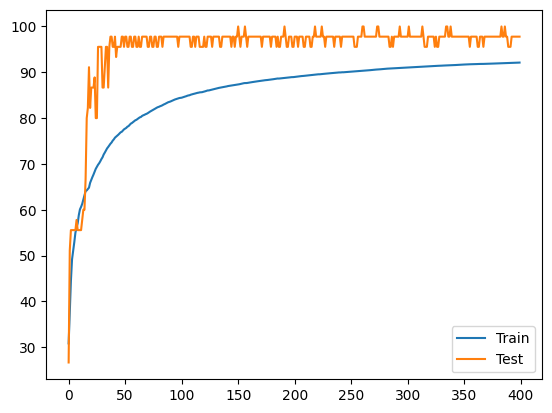

In [140]:
epochs=400
plt.plot(range(epochs) , train_acc)
plt.plot(range(epochs) , test_acc)
plt.legend(['Train','Test'])